Importação de Bibliotecas

In [21]:
import plotly.express as px
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

Atribuição de DataFrames

In [22]:
df_data = pd.read_csv('rest_data_us_upd.csv', dtype={'object_type': 'category'})

Pré-Análise do DataFrame

In [23]:
df_data.info()
df_data.describe()
print(df_data.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9651 non-null   int64   
 1   object_name  9651 non-null   object  
 2   address      9651 non-null   object  
 3   chain        9648 non-null   object  
 4   object_type  9651 non-null   category
 5   number       9651 non-null   int64   
dtypes: category(1), int64(2), object(3)
memory usage: 386.8+ KB
         id                object_name                            address  \
1859  13645           EL AGUILA BAKERY             5028 S HUNTINGTON DR S   
1746  13532     VIVA TACOS LA ESTRELLA              3733 1/2 N MISSION RD   
4241  16027       LITTLE CAESARS #5922                     4431 S MAIN ST   
3352  15138              BURGER PALACE                 7126 S WESTERN AVE   
9132  20918                 TONY'S BAR                   4310 W PICO BLVD   
248   12034            

In [24]:
df_data['object_type'].nunique()
df_data['object_type'].unique()
df_data['object_type'].value_counts()

object_type
Restaurant    7255
Fast Food     1066
Cafe           435
Pizza          320
Bar            292
Bakery         283
Name: count, dtype: int64

In [25]:
df_data = df_data.dropna(subset=['chain'])
df_data['chain'].unique()

array([False, True], dtype=object)

In [26]:
df_data['chain'] = df_data['chain'].astype(bool)

In [27]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9648 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9648 non-null   int64   
 1   object_name  9648 non-null   object  
 2   address      9648 non-null   object  
 3   chain        9648 non-null   bool    
 4   object_type  9648 non-null   category
 5   number       9648 non-null   int64   
dtypes: bool(1), category(1), int64(2), object(2)
memory usage: 395.9+ KB


In [28]:
df_data.duplicated().sum()

np.int64(0)

Passo 2. Análise de dados

Investigue as proporções de vários tipos de estabelecimentos. Construa um gráfico.

In [29]:
data_proportion_store = df_data['object_type'].value_counts().reset_index()
print(data_proportion_store)

  object_type  count
0  Restaurant   7253
1   Fast Food   1066
2        Cafe    435
3       Pizza    319
4         Bar    292
5      Bakery    283


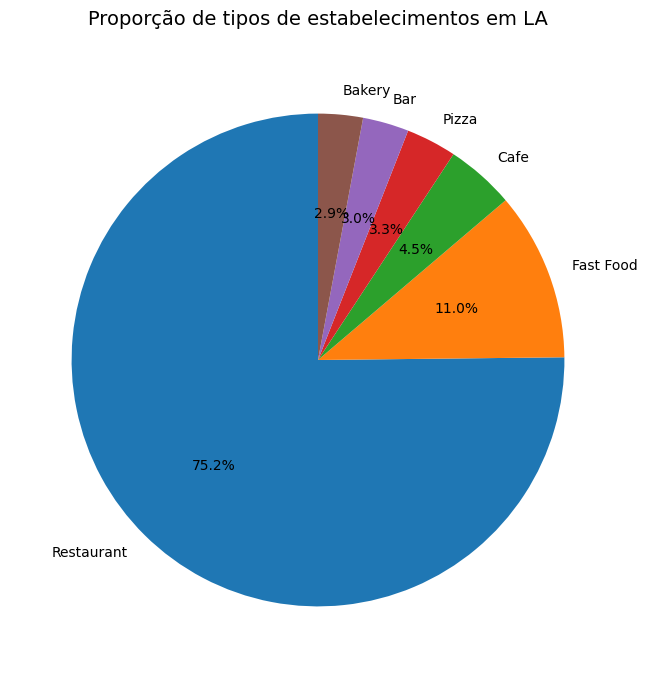

In [30]:
plt.figure(figsize=(12, 8))
plt.pie(data_proportion_store['count'], labels=data_proportion_store['object_type'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de tipos de estabelecimentos em LA', fontsize=14, pad=20)
plt.show()

A partir dos dados de proporção de tipos de estabelecimentos na cidade de Los Angeles, dá pra ver que 75% do mercado é dominado por restaurantes, em segundo lugar estando os fast food com 11% do mercado, enquanto outros tipos de estabelecimento aparecem com baixa presença no mercado, como por exemplo cafeterias com 4,5%. Isso pode indicar tanto uma oportunidade de mercado pouco explorado quanto uma menor demanda por esses tipos de estabelecimento na região.

Investigue as proporções de estabelecimentos de rede e não. Construa um gráfico.

In [31]:
data_proportion_franchise = df_data['chain'].value_counts().reset_index()
print(data_proportion_franchise)

   chain  count
0  False   5972
1   True   3676


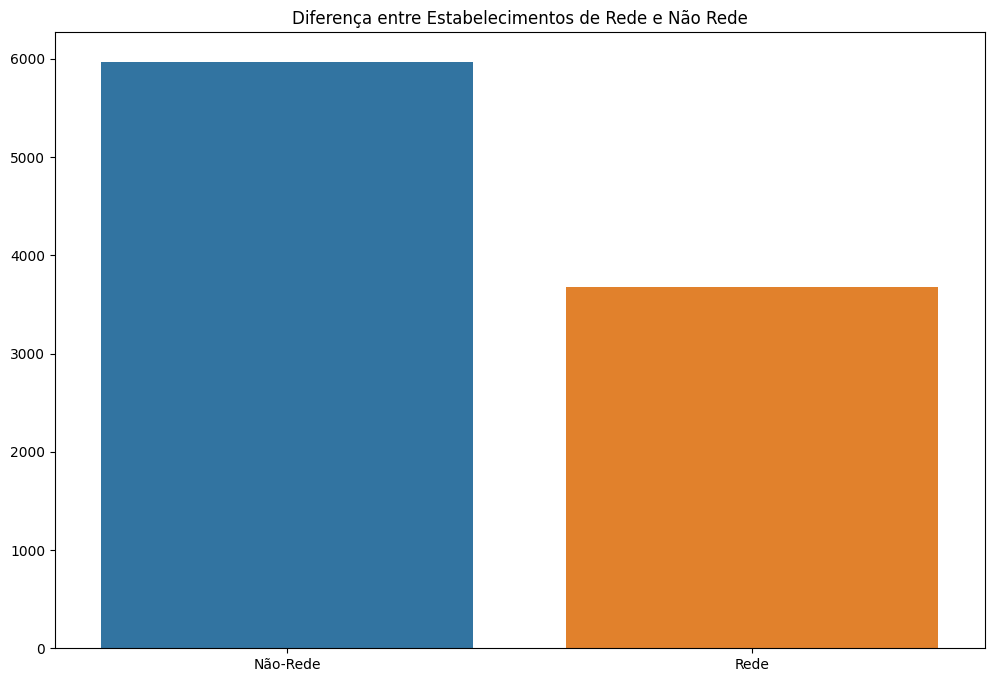

In [32]:
data_proportion_franchise['chain'] = data_proportion_franchise['chain'].map({True: 'Rede', False: 'Não-Rede'})
plt.figure(figsize=(12,8))
sns.barplot(data= data_proportion_franchise, x='chain', y='count', hue='chain')
plt.xlabel('')
plt.ylabel('')
plt.title('Diferença entre Estabelecimentos de Rede e Não Rede')
plt.show()


Aqui vemos que a maioria dos estabelecimentos de Los Angeles não faz parte de uma rede comercial, representando cerca de 60% do mercado os sem filiação

Qual tipo de estabelecimento é típico para redes?

In [33]:
data_franchise_store = df_data[df_data['chain'] == True]['object_type'].value_counts().reset_index()
print(data_franchise_store)

  object_type  count
0  Restaurant   2292
1   Fast Food    605
2      Bakery    283
3        Cafe    266
4       Pizza    153
5         Bar     77


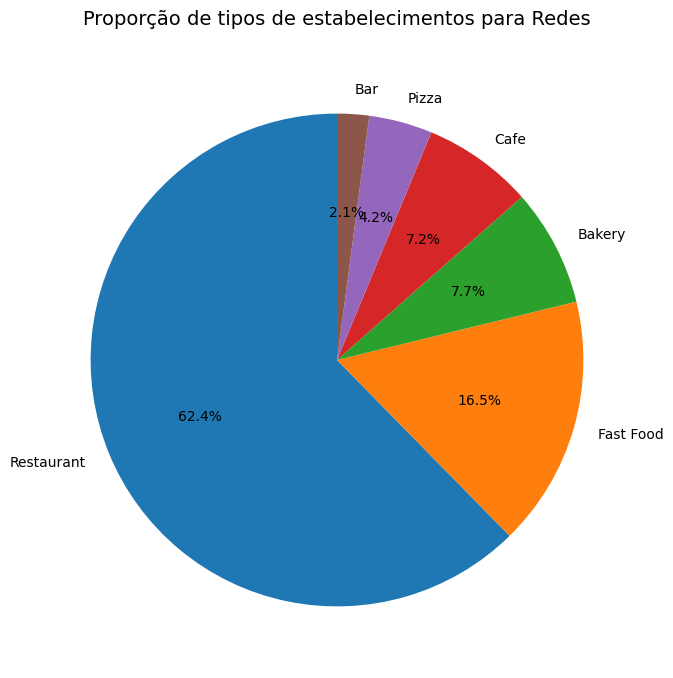

In [34]:
plt.figure(figsize=(12, 8))
plt.pie(data_franchise_store['count'], labels=data_franchise_store['object_type'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de tipos de estabelecimentos para Redes', fontsize=14, pad=20)
plt.show()

Como visto no primeiro gráfico, restaurantes dominam o mercado geral com 75%, mas entre as redes essa proporção cai para 62%. Em contrapartida, o Fast Food sobe de 11% para 16.5% nas redes, o que faz sentido dado que esse tipo de estabelecimento tem um modelo de negócio mais padronizado e fácil de escalar. Bakery também chama atenção — representa apenas 2.9% do mercado geral mas 7.7% das redes, sugerindo que padarias têm uma tendência maior à franquia.

O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

In [35]:
data_chairs_count = df_data.groupby('object_type')['number'].sum()
print(data_chairs_count)

object_type
Bakery          6162
Bar            13072
Cafe           10875
Fast Food      33939
Pizza           9106
Restaurant    348498
Name: number, dtype: int64


C:\Users\gamer\AppData\Local\Temp\ipykernel_16392\4257056875.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_chairs_count = df_data.groupby('object_type')['number'].sum()


In [36]:
df_data.groupby('chain')['number'].mean()

chain
False    46.171467
True     39.694233
Name: number, dtype: float64

In [37]:
df_data[df_data['chain'] == True].groupby('object_name')['id'].count().sort_values(ascending=False).head(10)

object_name
THE COFFEE BEAN & TEA LEAF    47
SUBWAY                        31
DOMINO'S PIZZA                15
KENTUCKY FRIED CHICKEN        14
WABA GRILL                    14
MCDONALD'S                    13
TRIMANA                       13
PAPA JOHN'S PIZZA             12
HONG KONG EXPRESS             12
STARBUCKS                     12
Name: id, dtype: int64

De acordo com os dados extraídos, redes se caracterizam por terem mais estabelecimentos e menos cadeiras, o que favorece as crenças de que redes priorizam a rotatividade maior de clientes dentro dos estabelecimentos

Determine o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos? Construa gráficos.

In [38]:
data_chairs_object_type = df_data.groupby('object_type')['number'].mean().reset_index()
print(data_chairs_object_type)

  object_type     number
0      Bakery  21.773852
1         Bar  44.767123
2        Cafe  25.000000
3   Fast Food  31.837711
4       Pizza  28.545455
5  Restaurant  48.048807


C:\Users\gamer\AppData\Local\Temp\ipykernel_16392\4199050570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_chairs_object_type = df_data.groupby('object_type')['number'].mean().reset_index()


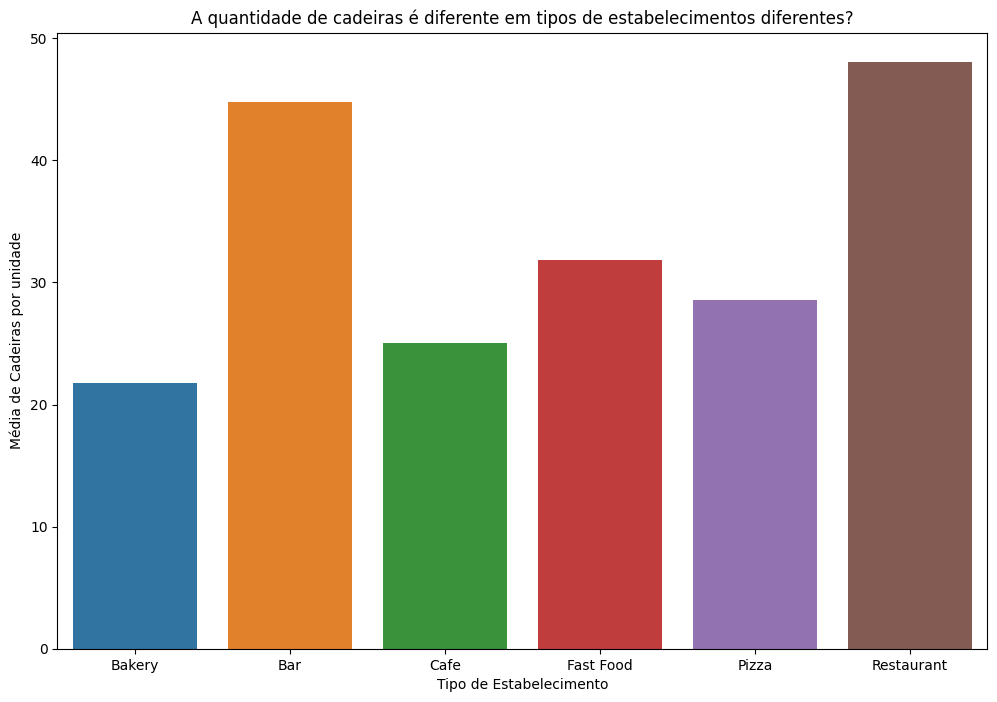

In [39]:
plt.figure(figsize=(12,8))
sns.barplot(data= data_chairs_object_type, x='object_type', y='number', hue='object_type')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Média de Cadeiras por unidade')
plt.title('A quantidade de cadeiras é diferente em tipos de estabelecimentos diferentes?')
plt.show()


Estabelecimentos focados atender o cliente por um tempo maior, como um Restaurante ou um Bar tendem a ter um número médio maior de cadeiras por estabelecimento(48 e 44) enquanto padarias que geralmente realizam o atendimento em um tempo mais rápido tem menos cadeiras(21)